<a href="https://colab.research.google.com/github/kayeneii/Floodgate/blob/main/data_collection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mapping Flood Risk Zones in Lagos Using Open Data

## *Step 1: Data Collection*
- Choose study area and export small rasters from GEE to test.

- Define a bounding box (min lon, min lat, max lon, max lat).

- Use this to preview DEM, rivers, and rainfall quickly.

Open: https://code.earthengine.google.com/cd290a1d5be41113879d68813786bc9a

## *Step 2: Preprocessing*

- Authenticate: Earth Engine & Google Drive.

- Define study area and date window.

- Query CHIRPS and check collection size — stop with a clear message if 0.

- Aggregate (sum) and reproject to DEM projection.

- Export images to Drive using ee.batch.Export.image.toDrive() and start the tasks

- Poll / print task.status() to know how it started.

In [1]:
# Colab setup: install required Python packages
!pip install rioxarray rasterio geopandas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 59.8 MB/s eta 0:00:00


In [2]:
import os, math
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import numpy as np
import ee, time

In [3]:
# Authenticate EE and mount Google Drive
ee.Authenticate()   # follow interactive prompt
ee.Initialize(project="thinking-league-472119-r1")

In [6]:
from google.colab import drive
drive.mount('/content/drive')
drive_base = '/content/drive/MyDrive/GEE_Floodgate'
out_dir = '/content/drive/MyDrive/GEE_Floodgate/processed'                       # outputs in Colab workspace
os.makedirs(out_dir, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Define key file paths
chirps_fp = os.path.join(drive_base, 'chirps_total_20250401_20250630_lagos.tif')
dem_fp = os.path.join(drive_base, 'srtm_dem_lagos.tif')
slope_fp = os.path.join(drive_base, 'srtm_slope_lagos.tif')
hillshade_fp = os.path.join(drive_base, 'hillshade_lagos.tif')

dem_utm_fp = os.path.join(out_dir, 'srtm_dem_lagos_utm.tif')
chirps_utm_fp = os.path.join(out_dir, 'chirps_lagos_utm.tif')
slope_utm_fp = os.path.join(out_dir, 'srtm_slope_lagos_utm.tif')
hillshade_utm_fp = os.path.join(out_dir, 'hillshade_lagos_utm.tif')

In [9]:
# Quick existence check
for p in [chirps_fp, dem_fp, slope_fp, hillshade_fp]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Required file not found: {p} - check your Drive path")

print("All input files found. Proceeding with reprojection and alignment...")

All input files found. Proceeding with reprojection and alignment...


### Reproject the DEM to an auto-selected UTM zone (based on DEM centroid).

In [22]:
# Determine UTM CRS automatically from DEM centroid and reproject DEM to UTM
with rasterio.open(dem_fp) as src:
    src_crs = src.crs
    bounds = src.bounds
    lon_centroid = (bounds.left + bounds.right) / 2.0
    lat_centroid = (bounds.top + bounds.bottom) / 2.0

    utm_zone = int((math.floor((lon_centroid + 180) / 6) % 60) + 1)
    hemisphere = '326' if lat_centroid >= 0 else '327'
    dst_crs = f"EPSG:{hemisphere}{utm_zone}"

    print(f"DEM source CRS: {src_crs}")
    print(f"Auto-selected UTM CRS: {dst_crs} (zone {utm_zone}, lat {lat_centroid:.4f})")

    # Compute transform for DEM -> UTM
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )
    meta = src.meta.copy()
    meta.update({
        'crs': dst_crs,
        'transform': transform,
        'width': width,
        'height': height
    })

    # Reproject DEM to UTM (bilinear for continuous surface)
    with rasterio.open(dem_utm_fp, 'w', **meta) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.bilinear
            )
print("Saved reprojected DEM ->", dem_utm_fp)

DEM source CRS: EPSG:4326
Auto-selected UTM CRS: EPSG:32631 (zone 31, lat 6.5396)
Saved reprojected DEM -> /content/drive/MyDrive/GEE_Floodgate/processed/srtm_dem_lagos_utm.tif


In [23]:
# Use DEM_UTM as reference grid; reproject other rasters to match its transform/shape
with rasterio.open(dem_utm_fp) as ref:
    ref_transform = ref.transform
    ref_crs = ref.crs
    ref_width = ref.width
    ref_height = ref.height
    ref_meta = ref.meta.copy()
    ref_res = ref.res[0]
    print("Reference grid: width, height =", ref_width, ref_height, "res (m) =", ref_res)

def reproject_to_ref(src_path, dst_path, resampling=Resampling.bilinear):
    with rasterio.open(src_path) as src:
        dst_meta = ref_meta.copy()
        dst_meta.update({'count': 1, 'dtype': src.meta['dtype']})
        # Prepare destination array filled with nodata
        dst_array = np.empty((ref_height, ref_width), dtype=src.meta['dtype'])
        reproject(
            source=rasterio.band(src, 1),
            destination=dst_array,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=resampling,
            num_threads=2
        )
        # Write out with reference metadata
        with rasterio.open(dst_path, 'w', **dst_meta) as dst:
            dst.write(dst_array, 1)
    print(f"Reprojected {os.path.basename(src_path)} -> {dst_path}")

Reference grid: width, height = 6095 1251 res (m) = 29.796267574316353


### Reproject CHIRPS, slope, and hillshade to match the DEM_UTM grid exactly (same transform, width, height) using bilinear resampling (appropriate for continuous rasters).

In [24]:
# Reproject CHIRPS (coarse source) -> match DEM grid (bilinear)
reproject_to_ref(chirps_fp, chirps_utm_fp, resampling=Resampling.bilinear)

Reprojected chirps_total_20250401_20250630_lagos.tif -> /content/drive/MyDrive/GEE_Floodgate/processed/chirps_lagos_utm.tif


In [25]:
# Reproject slope and hillshade (continuous surfaces)
reproject_to_ref(slope_fp, slope_utm_fp, resampling=Resampling.bilinear)
reproject_to_ref(hillshade_fp, hillshade_utm_fp, resampling=Resampling.bilinear)

Reprojected srtm_slope_lagos.tif -> /content/drive/MyDrive/GEE_Floodgate/processed/srtm_slope_lagos_utm.tif
Reprojected hillshade_lagos.tif -> /content/drive/MyDrive/GEE_Floodgate/processed/hillshade_lagos_utm.tif


In [26]:
# Quick verification: print CRS, bounds, min/max for each processed file
def quick_stats(path):
    import numpy as np
    with rasterio.open(path) as src:
        arr = src.read(1, masked=True)
        valid = np.isfinite(arr)
        vcount = int(valid.sum())
        mn = float(np.nanmin(arr)) if vcount>0 else np.nan
        mx = float(np.nanmax(arr)) if vcount>0 else np.nan
        print(os.path.basename(path))
        print("  CRS:", src.crs)
        print("  Shape:", src.width, "x", src.height)
        print("  Bounds:", src.bounds)
        print(f"  Valid pixels: {vcount:,}, min: {mn}, max: {mx}\n")

print("\n=== Verification of reprojected/aligned rasters ===")
quick_stats(dem_utm_fp)
quick_stats(chirps_utm_fp)
quick_stats(slope_utm_fp)
quick_stats(hillshade_utm_fp)

print("All done. Next: normalize layers and compute the Flood Risk Index (FRI).")


=== Verification of reprojected/aligned rasters ===
srtm_dem_lagos_utm.tif
  CRS: EPSG:32631
  Shape: 6095 x 1251
  Bounds: BoundingBox(left=467515.04494146263, bottom=704308.6565278268, right=649123.2958069209, top=741583.7872632965)
  Valid pixels: 7,624,845, min: -36.0, max: 77.0

chirps_lagos_utm.tif
  CRS: EPSG:32631
  Shape: 6095 x 1251
  Bounds: BoundingBox(left=467515.04494146263, bottom=704308.6565278268, right=649123.2958069209, top=741583.7872632965)
  Valid pixels: 3,969,065, min: 512.9857714428252, max: 804.4408504002384

srtm_slope_lagos_utm.tif
  CRS: EPSG:32631
  Shape: 6095 x 1251
  Bounds: BoundingBox(left=467515.04494146263, bottom=704308.6565278268, right=649123.2958069209, top=741583.7872632965)
  Valid pixels: 4,289,861, min: 0.0, max: 41.883575439453125

hillshade_lagos_utm.tif
  CRS: EPSG:32631
  Shape: 6095 x 1251
  Bounds: BoundingBox(left=467515.04494146263, bottom=704308.6565278268, right=649123.2958069209, top=741583.7872632965)
  Valid pixels: 4,289,861, 

## *Step 3: Flood Risk Index (FRI) Construction for Lagos*

In [36]:
# Define key file paths for FRI
base_dir = '/content/drive/MyDrive/GEE_Floodgate/processed'
dem_fp = os.path.join(base_dir, "srtm_dem_lagos_utm.tif")
chirps_fp = os.path.join(base_dir, "chirps_lagos_utm.tif")
slope_fp = os.path.join(base_dir, "srtm_slope_lagos_utm.tif")
fri_fp = os.path.join(base_dir, "fri_utm.tif")
fri_repaired_fp = os.path.join(base_dir, "fri_utm_repaired.tif")

In [29]:
!pip install rioxarray rasterio matplotlib scipy -q

In [30]:
import os
import numpy as np
import rioxarray as rxr
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation

In [37]:
# Step 1: Load rasters
print("Loading rasters...")
dem = rxr.open_rasterio(dem_fp, masked=True).squeeze()
chirps = rxr.open_rasterio(chirps_fp, masked=True).squeeze()
slope = rxr.open_rasterio(slope_fp, masked=True).squeeze()

Loading rasters...


In [38]:
# Step 2: Normalize each layer to 0–1
def normalize(arr):
    valid = arr.where(~np.isnan(arr), drop=True)
    vmin = float(valid.min())
    vmax = float(valid.max())
    norm = (arr - vmin) / (vmax - vmin)
    return norm.clip(0, 1)

rain_n = normalize(chirps)
elev_n = normalize(dem)
slope_n = normalize(slope)

print(f"Rainfall range (mm): {float(chirps.min()):.2f}–{float(chirps.max()):.2f}")
print(f"Elevation range (m): {float(dem.min()):.2f}–{float(dem.max()):.2f}")
print(f"Slope range (°): {float(slope.min()):.2f}–{float(slope.max()):.2f}")

Rainfall range (mm): 512.99–804.44
Elevation range (m): -36.00–77.00
Slope range (°): 0.00–41.88


In [39]:
# Step 3: Compute slope factor (low slope = high risk)
slope_factor = 1 - slope_n  # invert slope normalization

In [40]:
# Step 4: Combine layers with weights
w1, w2, w3 = 0.5, 0.35, 0.15  # rainfall, elevation, slope
fri = (w1 * rain_n) + (w2 * (1 - elev_n)) + (w3 * slope_factor)
fri = fri.where(~np.isnan(fri), np.nan)

fri.rio.write_crs(dem.rio.crs, inplace=True)
fri.rio.write_transform(dem.rio.transform(), inplace=True)
fri.rio.to_raster(fri_fp)
print("✅ FRI raster saved:", fri_fp)

✅ FRI raster saved: /content/drive/MyDrive/GEE_Floodgate/processed/fri_utm.tif


Notes on weights and normalization

- Default values are a starting point. Keep weights in a JSON so analysts can run sensitivity tests.

- Normalization uses min/max across the study area; for larger regions consider robust scaling (percentiles) to avoid outliers dominating.

In [41]:
# Step 5: Repair minor gaps
fri_filled = fri.copy()
mask_nan = fri.isnull()
fri_filled.values[mask_nan.values] = np.nanmean(fri.values)
fri_repaired = fri_filled.fillna(0).rio.write_crs(dem.rio.crs)
fri_repaired.rio.to_raster(fri_repaired_fp)
print("✅ Repaired FRI raster saved:", fri_repaired_fp)

✅ Repaired FRI raster saved: /content/drive/MyDrive/GEE_Floodgate/processed/fri_utm_repaired.tif


In [42]:
# Step 6: Summary statistics
arr = fri.values
valid = np.isfinite(arr)
vcount = valid.sum()
print("\n📊 FRI — Statistics Summary")
print(f"  • Valid pixels: {vcount:,}")
print(f"  • Min: {np.nanmin(arr):.3f}")
print(f"  • Max: {np.nanmax(arr):.3f}")
print(f"  • Mean: {np.nanmean(arr):.3f}")


📊 FRI — Statistics Summary
  • Valid pixels: 3,752,944
  • Min: 0.253
  • Max: 0.891
  • Mean: 0.629


### Interpretation:

A min FRI of 0.25 suggests that no part of the study area is entirely flood-safe (which fits Lagos’ coastal terrain).

The mean (0.63) and max (0.89) indicate substantial variability — likely high-risk zones near riverine or low-lying coastal districts.

The valid pixel count confirms full coverage and correct raster alignment.

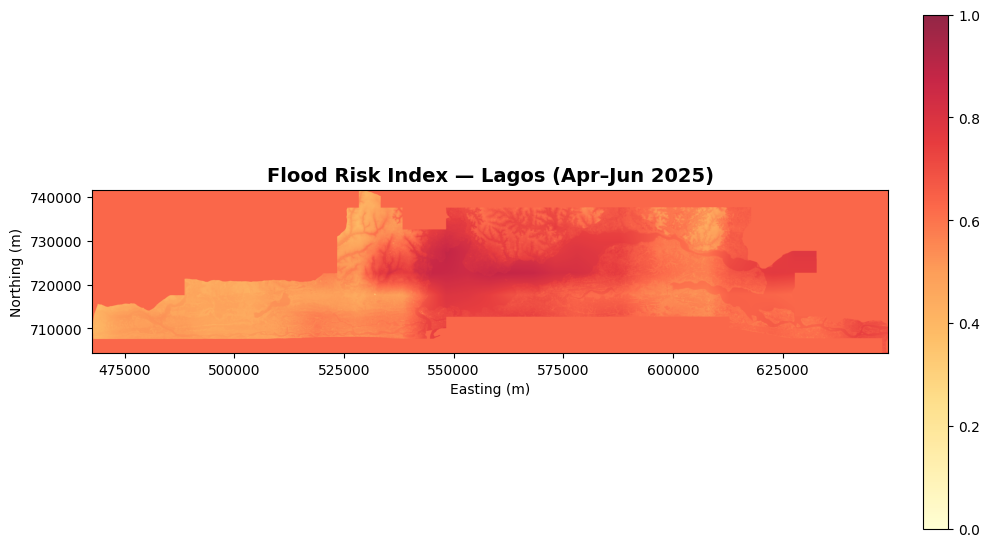

In [48]:
# Step 7: Visualization
import rasterio
from rasterio.plot import show

# Paths
base_dir = '/content/drive/MyDrive/GEE_Floodgate/processed'
fri_fp = fri_path = f"{base_dir}/fri_utm_repaired.tif"
hillshade_fp = f"{base_dir}/hillshade_lagos_utm.tif"

# Load rasters
fri = rasterio.open(fri_fp)
hillshade = rasterio.open(hillshade_fp)

# Load arrays
fri_data = fri.read(1, masked=True)
hill_data = hillshade.read(1, masked=True)

# Normalize hillshade for base contrast
hill_norm = (hill_data - hill_data.min()) / (hill_data.max() - hill_data.min())

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title("Flood Risk Index — Lagos (Apr–Jun 2025)", fontsize=14, fontweight='bold')

# Show hillshade as light background
ax.imshow(hill_norm, cmap='Greys', alpha=0.5, extent=(fri.bounds.left, fri.bounds.right, fri.bounds.bottom, fri.bounds.top))

# Show FRI with strong color ramp
im = ax.imshow(fri_data, cmap='YlOrRd', alpha=0.85, extent=(fri.bounds.left, fri.bounds.right, fri.bounds.bottom, fri.bounds.top), vmin=0, vmax=1)

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)

# Label axes
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

plt.tight_layout()
plt.show()